In [34]:
from pathlib import Path

import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

data_path = Path("Backfeed_Data300.xlsx")
geometry_columns = ["L", "W", "Q", "sx", "sy", "sl", "sw"]
response_start_column = 16

raw_data = pd.read_excel(data_path, header=0)
labels = raw_data.loc[:, geometry_columns].apply(pd.to_numeric, errors="raise")

# 第 17 列到最后一列全部是 S11，共 1001 个频点。
response_db = raw_data.iloc[:, response_start_column:].apply(
    pd.to_numeric,
    errors="raise",
)
frequency = pd.to_numeric(response_db.columns, errors="raise").to_numpy()
y_db = response_db.to_numpy(dtype=np.float32)

# 当前数据中 L、W、Q 是常量，实际变化的输入为 sx、sy、sl、sw。
feature_columns = [
    column for column in geometry_columns if labels[column].nunique() > 1
]
X = labels.loc[:, feature_columns].to_numpy(dtype=np.float32)

all_indices = np.arange(len(raw_data))
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.3,
    random_state=SEED,
    shuffle=True,
)

# 变换只使用训练集拟合，避免验证集信息泄漏。
x_scaler = StandardScaler().fit(X[train_indices])
X_scaled = x_scaler.transform(X).astype(np.float32)

pca_dim = 50
pca = PCA(n_components=pca_dim).fit(y_db[train_indices])
y_coefficients = pca.transform(y_db).astype(np.float32)
coefficient_scaler = StandardScaler().fit(y_coefficients[train_indices])
y_coefficients_scaled = coefficient_scaler.transform(
    y_coefficients
).astype(np.float32)

X_train = torch.tensor(X_scaled[train_indices])
X_val = torch.tensor(X_scaled[val_indices])
y_train_db = torch.tensor(y_db[train_indices])
y_val_db = torch.tensor(y_db[val_indices])
y_train_coefficients = torch.tensor(
    y_coefficients_scaled[train_indices]
)

input_dim = len(feature_columns)
output_points = y_db.shape[1]

print(f"完整 S11 点数: {output_points}")
print(f"频率范围: {frequency[0]:.4f} - {frequency[-1]:.4f} GHz")
print(f"有效输入列: {feature_columns}")
print(
    f"PCA {pca_dim} 个分量解释率: "
    f"{pca.explained_variance_ratio_.sum():.6%}"
)


完整 S11 点数: 1001
频率范围: 2.0000 - 2.6000 GHz
有效输入列: ['sx', 'sy', 'sl', 'sw']
PCA 50 个分量解释率: 99.985904%


In [35]:
class FullBandPCANet(nn.Module):
    def __init__(self, input_dim, pca_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, pca_dim),
        )

    def forward(self, x):
        return self.network(x)


def decode_coefficients(scaled_coefficients):
    coefficients = (
        scaled_coefficients * coefficient_scale_tensor
        + coefficient_mean_tensor
    )
    return coefficients @ pca_components_tensor + pca_mean_tensor


def weighted_curve_loss(predicted_db, true_db):
    # 深谐振谷只占少数频点，增加这些点的权重，防止被大量接近 0 dB 的点淹没。
    weights = 1 + 20 * (torch.clamp(-true_db, min=0) / 40) ** 2
    return torch.mean(weights * (predicted_db - true_db) ** 2)


def predict_full_curve(model, scaled_inputs):
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(
            scaled_inputs,
            dtype=torch.float32,
            device=device,
        )
        return decode_coefficients(model(inputs)).cpu().numpy()


def curve_metrics(true_db, predicted_db):
    error = predicted_db - true_db
    true_min_index = np.argmin(true_db, axis=1)
    predicted_min_index = np.argmin(predicted_db, axis=1)
    rows = np.arange(len(true_db))
    return {
        "MAE (dB)": np.mean(np.abs(error)),
        "RMSE (dB)": np.sqrt(np.mean(error**2)),
        "Resonance frequency MAE (GHz)": np.mean(
            np.abs(
                frequency[predicted_min_index]
                - frequency[true_min_index]
            )
        ),
        "Resonance depth MAE (dB)": np.mean(
            np.abs(
                predicted_db[rows, predicted_min_index]
                - true_db[rows, true_min_index]
            )
        ),
    }


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FullBandPCANet(input_dim, pca_dim).to(device)

X_train_device = X_train.to(device)
X_val_device = X_val.to(device)
y_train_db_device = y_train_db.to(device)
y_val_db_device = y_val_db.to(device)
y_train_coefficients_device = y_train_coefficients.to(device)

pca_components_tensor = torch.tensor(
    pca.components_,
    dtype=torch.float32,
    device=device,
)
pca_mean_tensor = torch.tensor(
    pca.mean_,
    dtype=torch.float32,
    device=device,
)
coefficient_mean_tensor = torch.tensor(
    coefficient_scaler.mean_,
    dtype=torch.float32,
    device=device,
)
coefficient_scale_tensor = torch.tensor(
    coefficient_scaler.scale_,
    dtype=torch.float32,
    device=device,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)
max_epochs = 5000
patience_limit = 500
best_val_loss = float("inf")
best_epoch = 0
best_state = None
patience = 0
train_losses = []
val_losses = []

for epoch in range(max_epochs):
    model.train()
    optimizer.zero_grad()

    train_coefficients = model(X_train_device)
    train_curve = decode_coefficients(train_coefficients)
    train_loss = weighted_curve_loss(
        train_curve,
        y_train_db_device,
    )
    # 轻微约束 PCA 系数，提升训练稳定性。
    train_loss = train_loss + 0.01 * torch.mean(
        (train_coefficients - y_train_coefficients_device) ** 2
    )
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_curve = decode_coefficients(model(X_val_device))
        val_loss = weighted_curve_loss(
            val_curve,
            y_val_db_device,
        )

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss - 1e-6:
        best_val_loss = val_loss.item()
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        patience = 0
    else:
        patience += 1

    if (epoch + 1) % 200 == 0 or epoch == 0:
        print(
            f"epoch={epoch + 1:04d}, train={train_loss.item():.6f}, "
            f"val={val_loss.item():.6f}"
        )

    if patience >= patience_limit:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_state)
predicted_db = predict_full_curve(model, X_scaled)

print(f"最佳 epoch: {best_epoch}")
print("训练集完整曲线指标:")
display(
    pd.Series(
        curve_metrics(y_db[train_indices], predicted_db[train_indices])
    ).to_frame("Value")
)
print("验证集完整曲线指标:")
display(
    pd.Series(
        curve_metrics(y_db[val_indices], predicted_db[val_indices])
    ).to_frame("Value")
)

model_package = {
    "model_state": model.state_dict(),
    "feature_columns": feature_columns,
    "x_mean": x_scaler.mean_,
    "x_scale": x_scaler.scale_,
    "coefficient_mean": coefficient_scaler.mean_,
    "coefficient_scale": coefficient_scaler.scale_,
    "pca_components": pca.components_,
    "pca_mean": pca.mean_,
    "frequency": frequency,
    "input_dim": input_dim,
    "pca_dim": pca_dim,
}
torch.save(model_package, "model_forward_full_pca.pth")
print("模型已保存到 model_forward_full_pca.pth")


epoch=0001, train=51.331558, val=54.013592
epoch=0200, train=7.028032, val=10.592337
epoch=0400, train=2.209394, val=7.919833
epoch=0600, train=0.859438, val=7.726633
epoch=0800, train=0.456563, val=7.947269
epoch=1000, train=0.301226, val=8.213305
Early stopping at epoch 1148
最佳 epoch: 648
训练集完整曲线指标:


,Value
MAE (dB),0.217098
RMSE (dB),0.527536
Resonance frequency MAE (GHz),0.001046
Resonance depth MAE (dB),1.518832


验证集完整曲线指标:


,Value
MAE (dB),0.394440
RMSE (dB),1.244039
Resonance frequency MAE (GHz),0.004280
Resonance depth MAE (dB),4.363995


模型已保存到 model_forward_full_pca.pth


数据索引: 0，Excel 行号: 2
真实谷底: -40.394 dB @ 2.3894 GHz
预测谷底: -39.239 dB @ 2.3894 GHz


,Frequency_GHz,True_dB,Predicted_dB,Error_dB
0,2.0000,-0.077324,-0.091454,-0.014130
1,2.0006,-0.080257,-0.094925,-0.014669
2,2.0012,-0.083062,-0.098207,-0.015145
3,2.0018,-0.085733,-0.101264,-0.015532
4,2.0024,-0.088261,-0.104013,-0.015752
...,...,...,...,...
996,2.5976,-0.286520,-0.343747,-0.057227
997,2.5982,-0.278630,-0.335245,-0.056615
998,2.5988,-0.270739,-0.326517,-0.055779
999,2.5994,-0.262873,-0.317589,-0.054716


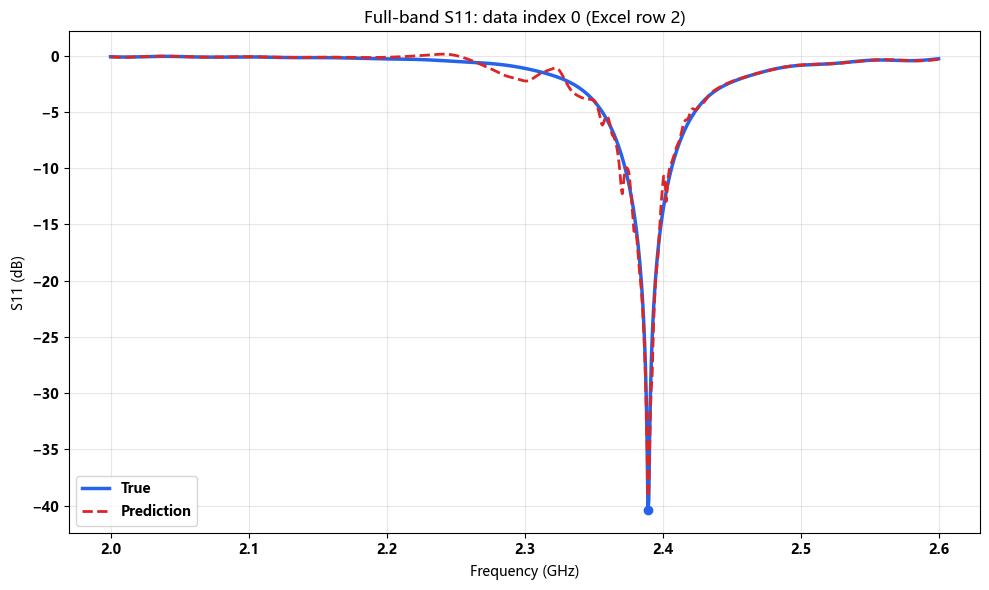

In [37]:
# 这里明确使用 DataFrame 的零基索引。
# sample_index=0 是 Excel 第 2 行（第 1 条数据，Excel 第 1 行是表头）。
sample_index = 0

true_curve = y_db[sample_index].astype(np.float64)
predicted_curve = predicted_db[sample_index].astype(np.float64)
true_min_index = int(np.argmin(true_curve))
predicted_min_index = int(np.argmin(predicted_curve))

print(f"数据索引: {sample_index}，Excel 行号: {sample_index + 2}")
print(
    f"真实谷底: {true_curve[true_min_index]:.3f} dB @ "
    f"{frequency[true_min_index]:.4f} GHz"
)
print(
    f"预测谷底: {predicted_curve[predicted_min_index]:.3f} dB @ "
    f"{frequency[predicted_min_index]:.4f} GHz"
)

comparison_table = pd.DataFrame(
    {
        "Frequency_GHz": frequency,
        "True_dB": true_curve,
        "Predicted_dB": predicted_curve,
        "Error_dB": predicted_curve - true_curve,
    }
)
display(comparison_table)

plt.figure(figsize=(10, 6))
plt.plot(
    frequency,
    true_curve,
    color="#2563EB",
    linewidth=2.5,
    label="True",
)
plt.plot(
    frequency,
    predicted_curve,
    color="#DC2626",
    linewidth=2,
    linestyle="--",
    label="Prediction",
)
plt.scatter(
    frequency[true_min_index],
    true_curve[true_min_index],
    color="#2563EB",
    zorder=3,
)
plt.xlabel("Frequency (GHz)")
plt.ylabel("S11 (dB)")
plt.title(
    f"Full-band S11: data index {sample_index} "
    f"(Excel row {sample_index + 2})"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


截图候选: 数据索引 10, Excel 行号 12
谷底: -21.885 dB @ 2.3456 GHz, 点索引=576


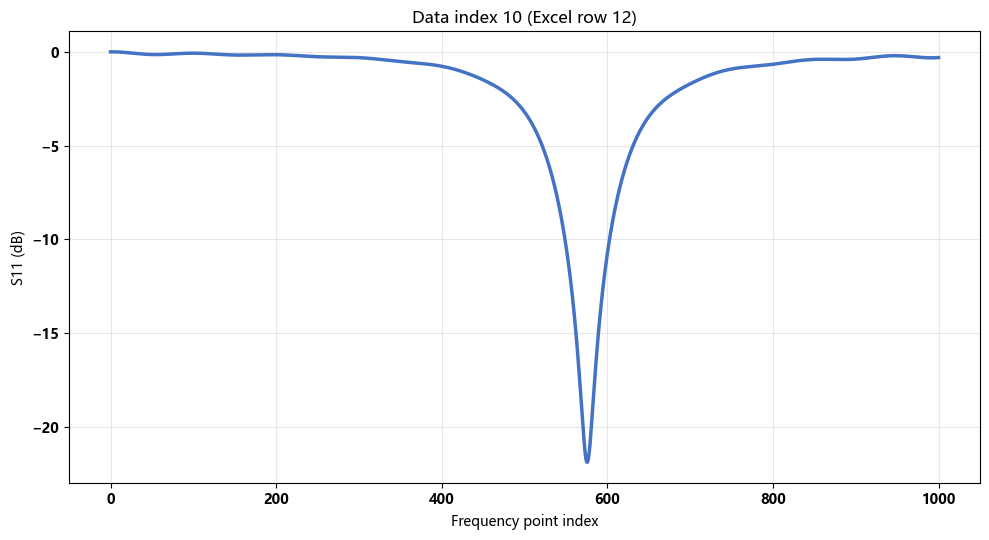

In [38]:
# 你的截图大概率对应数据索引 10（Excel 第 12 行）：
# 谷底约 -21.885 dB，位于第 576 个点附近。
screenshot_candidate_index = 10
screenshot_curve = y_db[screenshot_candidate_index]
screenshot_min_index = int(np.argmin(screenshot_curve))

print(
    f"截图候选: 数据索引 {screenshot_candidate_index}, "
    f"Excel 行号 {screenshot_candidate_index + 2}"
)
print(
    f"谷底: {screenshot_curve[screenshot_min_index]:.3f} dB @ "
    f"{frequency[screenshot_min_index]:.4f} GHz, "
    f"点索引={screenshot_min_index}"
)

plt.figure(figsize=(10, 5.5))
plt.plot(
    np.arange(output_points),
    screenshot_curve,
    color="#4472C4",
    linewidth=2.5,
)
plt.xlabel("Frequency point index")
plt.ylabel("S11 (dB)")
plt.title(
    f"Data index {screenshot_candidate_index} "
    f"(Excel row {screenshot_candidate_index + 2})"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


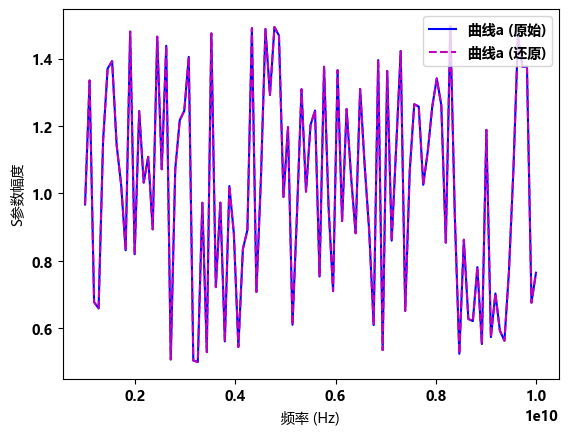

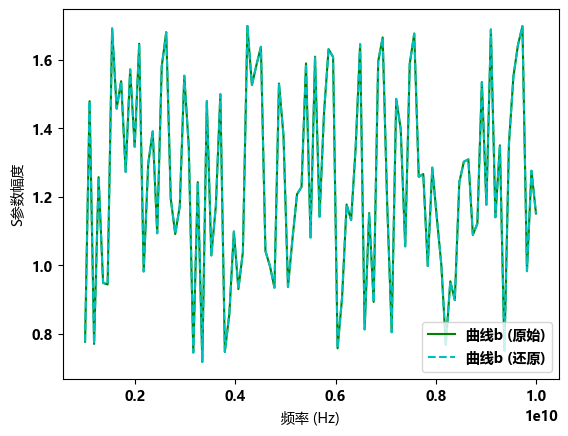

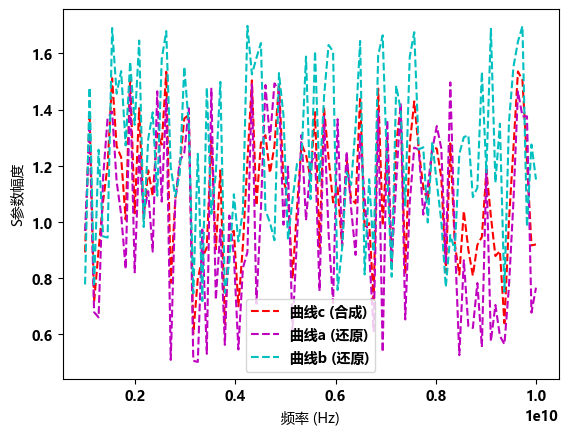

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font",family='MicroSoft YaHei',weight="bold")

# 生成示例频率数据
freq = np.linspace(1e9, 10e9, 101)  # 频率范围：1 GHz 到 10 GHz

# 随机生成示例S参数数据，曲线a和曲线b
S_a = np.random.rand(len(freq)) + 0.5
S_b = np.random.rand(len(freq)) + 0.7

# 合成曲线c（线性组合曲线a和曲线b）
w_a = 0.6  # 曲线a的权重
w_b = 0.4  # 曲线b的权重
S_c = w_a * S_a + w_b * S_b

# 计算还原的曲线a和曲线b的S参数
restored_S_a = (S_c - w_b * S_b) / w_a
restored_S_b = (S_c - w_a * S_a) / w_b

# 绘制曲线a的原始样子
plt.figure()
plt.plot(freq, S_a, 'b-', label='曲线a (原始)')
plt.plot(freq, restored_S_a, 'm--', label='曲线a (还原)')
plt.xlabel('频率 (Hz)')
plt.ylabel('S参数幅度')
plt.legend()

# 绘制曲线b的原始样子
plt.figure()
plt.plot(freq, S_b, 'g-', label='曲线b (原始)')
plt.plot(freq, restored_S_b, 'c--', label='曲线b (还原)')
plt.xlabel('频率 (Hz)')
plt.ylabel('S参数幅度')
plt.legend()

# 绘制合成的曲线c和还原的曲线a和曲线b
plt.figure()
plt.plot(freq, S_c, 'r--', label='曲线c (合成)')
plt.plot(freq, restored_S_a, 'm--', label='曲线a (还原)')
plt.plot(freq, restored_S_b, 'c--', label='曲线b (还原)')
plt.xlabel('频率 (Hz)')
plt.ylabel('S参数幅度')
plt.legend()

plt.show()



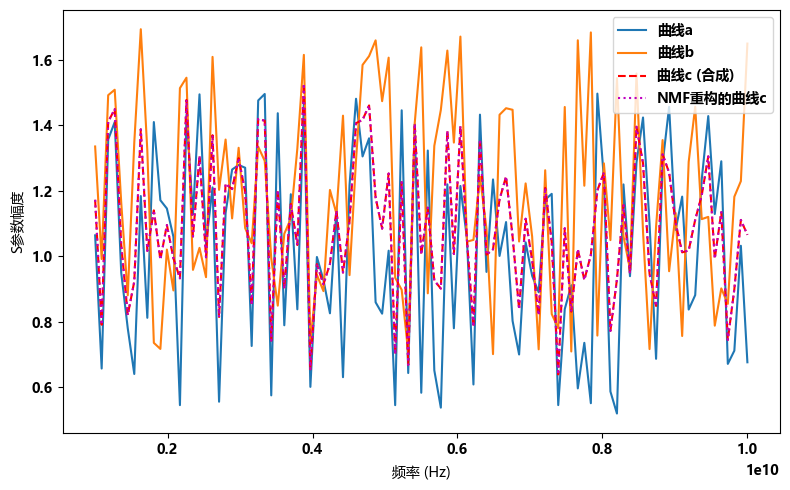

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

# NMF 只能重构观测矩阵；仅凭一条混合曲线无法唯一恢复两条原始曲线。
freq = np.linspace(1e9, 10e9, 101)
S_a = np.random.rand(len(freq)) + 0.5
S_b = np.random.rand(len(freq)) + 0.7
S_c = 0.6 * S_a + 0.4 * S_b

observations = np.column_stack([S_c, np.zeros_like(S_c)])
nmf = NMF(n_components=2, init="random", random_state=42, max_iter=1000)
W = nmf.fit_transform(observations)
H = nmf.components_
reconstructed_c = (W @ H)[:, 0]

plt.figure(figsize=(8, 5))
plt.plot(freq, S_a, label="曲线a")
plt.plot(freq, S_b, label="曲线b")
plt.plot(freq, S_c, "r--", label="曲线c (合成)")
plt.plot(freq, reconstructed_c, "m:", label="NMF重构的曲线c")
plt.xlabel("频率 (Hz)")
plt.ylabel("S参数幅度")
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
# 查询当前系统所有字体
from matplotlib.font_manager import FontManager
import subprocess

mpl_fonts = set(f.name for f in FontManager().ttflist)

print('all font list get from matplotlib.font_manager:')
for f in sorted(mpl_fonts):
    print('\t' + f)

all font list get from matplotlib.font_manager:
	Arial
	Bahnschrift
	Book Antiqua
	Bookman Old Style
	Bookshelf Symbol 7
	Bradley Hand ITC
	Calibri
	Cambria
	Candara
	Century
	Century Gothic
	Comic Sans MS
	Consolas
	Constantia
	Corbel
	Courier New
	DIN Next LT Pro
	DejaVu Math TeX Gyre
	DejaVu Sans
	DejaVu Sans Display
	DejaVu Sans Mono
	DejaVu Serif
	DejaVu Serif Display
	DengXian
	Dubai
	Ebrima
	FFont-Family
	FZCuHeiSongS-B-GB
	FZShuTi
	FZXiaoBiaoSong-B05S
	FZYaoTi
	FangSong
	FangSong_GB2312
	Franklin Gothic Medium
	Freestyle Script
	French Script MT
	Gabriola
	Gadugi
	Garamond
	Georgia
	HONOR Sans CN
	HONOR Sans Design
	Impact
	Ink Free
	Javanese Text
	Juice ITC
	KaiTi
	Kingsoft UE
	Kristen ITC
	Leelawadee
	Leelawadee UI
	LiSu
	Lucida Console
	Lucida Handwriting
	Lucida Sans Unicode
	MS Gothic
	MS Reference Sans Serif
	MS Reference Specialty
	MT Extra
	MV Boli
	Malgun Gothic
	Microsoft Himalaya
	Microsoft JhengHei
	Microsoft New Tai Lue
	Microsoft PhagsPa
	Microsoft Sans Serif
	Mic